# Модели семейства ARIMA для предсказания стоимости акций

ARIMA модели - семейство моделей анализа временных рядов. Модель SARIMAX даже позволяет добавить внешние признаки, например, цены других акций, или стоимость индекса мосбиржи.

SARIMAX состоит из нескольких частей:
- **S** - сезонность
- **AR** - авторегрессия (зависимость текущего значения от предыдущих значений ряда)
- **I** - интегрирование (дифференцируем ряд, чтобы сделать его стационарным)
- **MA** - скользящее среднее (зависимость текущего значения от прошлых ошибок модели)
- **X** - eXogenous variables (внешние факторы)

# Функции

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm.auto import tqdm


def train_test_split_by_date(df, date_column='begin', target_column='close', test_size=0.2):
    """
    Разбивает данные на train/test по дате и возвращает X, y
    
    Args:
        df: DataFrame с колонкой 'begin'
        target_column: название целевой переменной
        test_size: доля тестовых данных (0.2 = 20%)
    """
    df = df.sort_values(date_column).reset_index(drop=True)
    
    # Вычисляем индекс разбиения
    split_idx = int(len(df) * (1 - test_size))
    
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    
    print(f"Train: {train_df[date_column].min()} - {train_df[date_column].max()} ({len(train_df)} samples)")
    print(f"Test:  {test_df[date_column].min()} - {test_df[date_column].max()} ({len(test_df)} samples)")
    
    # Удаляем колонку 'begin' и разделяем на X, y
    X_train = train_df.drop(columns=[date_column, target_column])
    y_train = train_df[target_column]
    
    X_test = test_df.drop(columns=[date_column, target_column])
    y_test = test_df[target_column]
    
    print(f"Признаков: {X_train.shape[1]}")
    
    return X_train, X_test, y_train, y_test

def visualize_predictions_comparison(
    results_df, title, y_label, date_column='begin', target_column='close', predict_column='predict',):
    """
    Визуализирует сравнение предсказаний и реальных изменений цены
    
    Args:
        results_df: DataFrame
        title: str, заголовок графика
        y_label: str, название оси Y
        date_column: str, название столбца с датой
        target_column: str, название столбца с target значениями
        predict_column: str, название столбца с предсказанными значениями
    """
    # Конвертируем дату если нужно
    if results_df[date_column].dtype == 'object':
        results_df = results_df.copy()
        results_df[date_column] = pd.to_datetime(results_df[date_column])
    
    # Сортируем по дате
    results_df = results_df.sort_values(date_column)
    
    fig = go.Figure()

    # Target
    fig.add_trace(
        go.Scatter(
            x=results_df[date_column],
            y=results_df[target_column],
            mode="lines+markers",
            name="target",
            line=dict(width=3, color="#2E8B57"),
            marker=dict(symbol="circle", size=6),
            opacity=0.8
        )
    )

    # Prediction
    fig.add_trace(
        go.Scatter(
            x=results_df[date_column],
            y=results_df[predict_column],
            mode="lines+markers",
            name="prediction",
            line=dict(width=3, color="#DC143C"),
            marker=dict(symbol="square", size=6),
            opacity=0.8
        )
    )

    # Нулевая линия
    fig.add_hline(
        y=0,
        line_width=1,
        line_dash="solid",
        line_color="black",
        opacity=0.5
    )

    fig.update_layout(
        title=dict(
            text=title,
            x=0.5,
            xanchor="center",
            font=dict(size=18)
        ),
        xaxis_title="Дата",
        yaxis_title=y_label,
        template="plotly_white",
        width=1200,
        height=600,
        hovermode="x unified"
    )

    fig.update_xaxes(
        tickangle=45,
        showgrid=True
    )

    fig.update_yaxes(
        showgrid=True
    )

    fig.show()

def evaluate_regression(y_test, y_pred, model_name=""):
    """Оценивает результаты регрессии"""
    print(f"\n{'='*50}")
    print(f"📊 МОДЕЛЬ: {model_name}")
    print(f"{'='*50}")
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    # Accuracy направления (важно для торговли)
    direction_accuracy = np.mean((y_test > 0) == (y_pred > 0))
    
    print(f"MAE: {mae:.4f}%")
    print(f"RMSE: {rmse:.4f}%")
    print(f"R²: {r2:.4f}")
    print(f"Accuracy направления: {direction_accuracy:.4f}")

    return {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "direction_accuracy": direction_accuracy,
    }

def add_target_after_time_delta(df, time_delta, date_column='begin', price_column='close', target_date_column='target_date', target_price_column='target'):
    """Добавляет столбец с целевой переменной - изменением цены через time_delta дней"""
    df = df.copy()
    df[target_price_column] = df[price_column].shift(-time_delta)
    df[target_date_column] = df[date_column].shift(-time_delta)
    return df

In [2]:
def log_return(series, periods=1):
    return np.log(series / series.shift(periods))


def inverse_log_return(log_ret, prev_price):
    return prev_price * np.exp(log_ret)

In [3]:
def _test_log_return():
    prices = pd.Series([100.0, 110.0, 121.0])
    log_ret = log_return(prices)
    log_ret_reversed = inverse_log_return(log_ret, prices.shift(1))
    assert np.allclose(prices[1:], log_ret_reversed[1:], rtol=1e-6)

_test_log_return()

In [4]:
def forward_log_return(series, periods: int = 1):
    """Лог-доходность на periods дней вперед"""
    return np.log(series.shift(-periods) / series)


def restore_current_price(log_ret, future_price):
    """Обратная функция лог-доходности: возвращает значение на основе будущего значения"""
    return future_price / np.exp(log_ret)

In [5]:
restore_current_price(forward_log_return(pd.Series([100.0, 110.0, 121.0])), pd.Series([110.0, 121.0, None]))

0    100.0
1    110.0
2      NaN
dtype: float64

In [6]:
def _test_forward_log_return():
    prices = pd.Series([100.0, 110.0, 121.0])
    log_ret = forward_log_return(prices)
    log_ret_reversed = restore_current_price(log_ret, prices.shift(-1))
    display(prices)
    display(log_ret_reversed)
    assert np.allclose(prices[:-1], log_ret_reversed[:-1], rtol=1e-6)

_test_forward_log_return()

0    100.0
1    110.0
2    121.0
dtype: float64

0    100.0
1    110.0
2      NaN
dtype: float64

## 1. Анализ стоимости акций

### 1.1. Загружаем данные

In [7]:
# Хак, чтобы добавить корень проекта в path для импорта модулей
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[1]))
sys.path

['/home/fiberfox/.local/share/uv/python/cpython-3.12.7-linux-x86_64-gnu/lib/python312.zip',
 '/home/fiberfox/.local/share/uv/python/cpython-3.12.7-linux-x86_64-gnu/lib/python3.12',
 '/home/fiberfox/.local/share/uv/python/cpython-3.12.7-linux-x86_64-gnu/lib/python3.12/lib-dynload',
 '',
 '/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor/.venv/lib/python3.12/site-packages',
 '/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor']

In [8]:
from datetime import datetime

date_start = datetime(2022, 5, 1)

In [9]:
from app.core.clients.moex import Boards, Engines, Interval, Markets, MOEXClient

moex_client = MOEXClient()
stocks_data = await moex_client.get_data(
    tickers=['GAZP', 'LKOH', 'ROSN', 'SBER'],
    engine=Engines.STOCK,
    market=Markets.SHARES,
    board=Boards.TQBR,
    start_date=date_start,
    end_date=datetime.now(),
    interval=Interval.HOUR_1,
)

In [10]:
stocks_data.keys()

dict_keys(['GAZP', 'LKOH', 'ROSN', 'SBER'])

In [11]:
stocks_data['GAZP'].describe()

,open,close,high,low,value,volume,begin,end
count,16432.000000,16432.000000,16432.000000,16432.000000,1.643200e+04,1.643200e+04,16432,16432
mean,151.301395,151.282688,151.718138,150.836521,4.839126e+08,3.226785e+06,2024-07-08 18:00:53.018500352,2024-07-08 19:00:41.901959424
min,105.620000,105.650000,105.850000,105.220000,3.017040e+04,2.600000e+02,2022-05-04 09:00:00,2022-05-04 09:59:59
25%,127.297500,127.270000,127.567500,126.900000,1.024791e+08,6.988950e+05,2023-07-17 21:45:00,2023-07-17 22:44:59
50%,143.625000,143.545000,143.990000,143.040000,2.483479e+08,1.655035e+06,2024-08-12 20:30:00,2024-08-12 21:29:59
75%,167.100000,167.082500,167.472500,166.725000,5.558015e+08,3.792495e+06,2025-07-11 14:15:00,2025-07-11 15:14:59
max,320.800000,320.800000,322.990000,319.590000,2.385369e+10,1.410863e+08,2026-04-19 18:00:00,2026-04-19 18:59:59
std,32.042218,32.023403,32.191107,31.860368,8.498380e+08,5.235373e+06,NaN,NaN


In [12]:
stocks_data['GAZP'].head()

,open,close,high,low,value,volume,begin,end,ticker
0,241.00,241.00,241.00,241.00,1.779544e+07,73840,2022-05-04 09:00:00,2022-05-04 09:59:59,GAZP
1,241.01,238.90,244.39,238.00,1.687852e+09,7012280,2022-05-04 10:00:00,2022-05-04 10:59:59,GAZP
2,238.95,233.80,240.20,233.50,1.187417e+09,5025080,2022-05-04 11:00:00,2022-05-04 11:59:59,GAZP
3,233.71,235.63,236.30,233.17,5.070772e+08,2159900,2022-05-04 12:00:00,2022-05-04 12:59:59,GAZP
4,235.63,234.61,235.84,233.90,3.604205e+08,1535620,2022-05-04 13:00:00,2022-05-04 13:59:59,GAZP


### 1.2. Обработка данных

In [13]:
# Возьмем только основную сессию

stocks_data_main_session = {}

for ticker, df in stocks_data.items():
    df = df.copy()
    df['hour'] = df['begin'].dt.hour
    # Основная сессия на Мосбирже: с 9:50 по 18:50.
    stocks_data_main_session[ticker] = df[df['hour'].between(10, 18)].drop(columns='hour')
    # Уберем выходные дни
    stocks_data_main_session[ticker] = stocks_data_main_session[ticker][stocks_data_main_session[ticker]['begin'].dt.dayofweek < 5]

stocks_data_main_session['GAZP'].shape

(9024, 9)

In [14]:
# Посмотрим на данные

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=stocks_data['GAZP']["begin"],
        y=stocks_data['GAZP']["close"],
        mode="lines",
        name="Close price"
    )
)

fig.update_layout(
    title="GAZP",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white"
)

fig.show()

### 1.3. Анализ цены акций

Пока попробуем проанализировать цены акций "в лоб" для бэйзлайна

In [15]:
# # Добавим разные таргеты:
# # - цена через час
# # - цена через день
# # - цена через неделю

# stocks_data_1h = {}
# stocks_data_1d = {}
# stocks_data_1w = {}

# for ticker, df in stocks_data.items():
#     stocks_data_1h[ticker] = add_target_after_time_delta(df, time_delta=1, date_column='begin', price_column='close', target_price_column='target')
#     stocks_data_1d[ticker] = add_target_after_time_delta(df, time_delta=24, date_column='begin', price_column='close', target_price_column='target')
#     stocks_data_1w[ticker] = add_target_after_time_delta(df, time_delta=24*7, date_column='begin', price_column='close', target_price_column='target')

# display(stocks_data_1h['GAZP'].head())
# stocks_data_1h['GAZP'].shape

In [16]:
# Сгруппируем по дням.

stocks_data_daily = {}
for ticker, df in stocks_data_main_session.items():
    stocks_data_daily[ticker] = df.resample('D', on='begin').last().dropna().reset_index()

display(stocks_data_daily['GAZP'].head())
stocks_data_daily['GAZP'].shape

,begin,open,close,high,low,value,volume,end,ticker
0,2022-05-04,234.25,234.16,234.80,234.16,249223456.1,1063310.0,2022-05-04 18:59:59,GAZP
1,2022-05-05,238.31,238.60,238.74,238.29,263457477.8,1104440.0,2022-05-05 18:59:59,GAZP
2,2022-05-06,240.04,240.10,240.65,239.98,367885098.9,1532000.0,2022-05-06 18:59:59,GAZP
3,2022-05-11,241.84,241.99,242.41,241.51,271818862.6,1122700.0,2022-05-11 18:59:59,GAZP
4,2022-05-12,233.50,230.56,233.93,230.30,460096965.5,1982820.0,2022-05-12 18:59:59,GAZP


(1003, 9)

In [17]:
stocks_data_daily['GAZP'][stocks_data_daily['GAZP']['begin'].dt.year == 2025].count()

begin     253
open      253
close     253
high      253
low       253
value     253
volume    253
end       253
ticker    253
dtype: int64

In [18]:
stocks_data_daily['GAZP'].tail(20)

,begin,open,close,high,low,value,volume,end,ticker
983,2026-03-23,131.55,132.21,132.29,130.81,8.471059e+08,6441270.0,2026-03-23 18:59:59,GAZP
984,2026-03-24,136.74,135.60,136.94,135.38,2.431411e+09,17858400.0,2026-03-24 18:59:59,GAZP
985,2026-03-25,136.37,136.67,136.79,136.18,9.000379e+08,6592490.0,2026-03-25 18:59:59,GAZP
986,2026-03-26,137.43,137.50,137.60,137.10,7.824337e+08,5694970.0,2026-03-26 18:59:59,GAZP
987,2026-03-27,135.86,136.56,136.62,135.50,6.900854e+08,5075940.0,2026-03-27 18:59:59,GAZP
988,2026-03-30,135.85,136.20,136.52,135.82,3.207450e+08,2355030.0,2026-03-30 18:59:59,GAZP
989,2026-03-31,133.93,134.38,134.70,133.93,5.675039e+08,4225120.0,2026-03-31 18:59:59,GAZP
990,2026-04-01,134.21,134.45,134.75,134.10,2.311305e+08,1718640.0,2026-04-01 18:59:59,GAZP
991,2026-04-02,133.37,133.70,133.81,133.30,2.003661e+08,1500360.0,2026-04-02 18:59:59,GAZP
992,2026-04-03,133.19,133.07,133.28,132.98,1.494895e+08,1122510.0,2026-04-03 18:58:08,GAZP


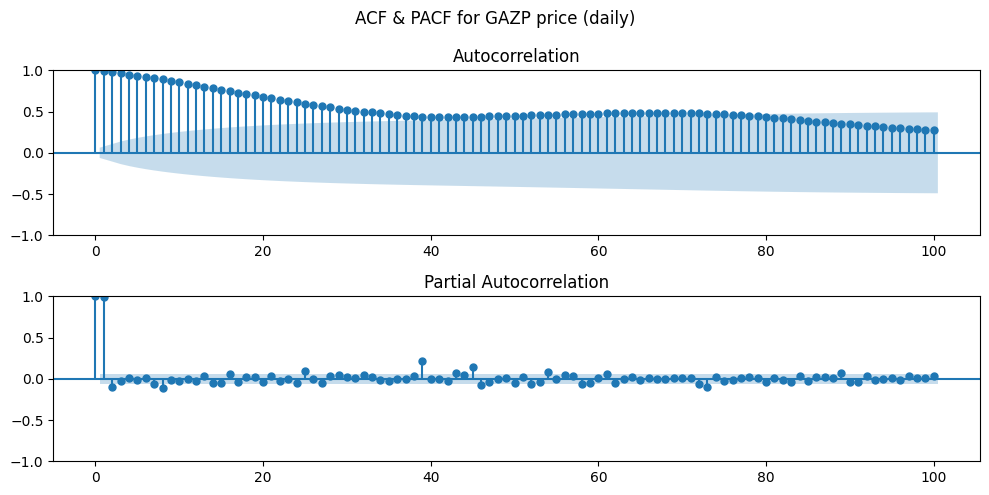

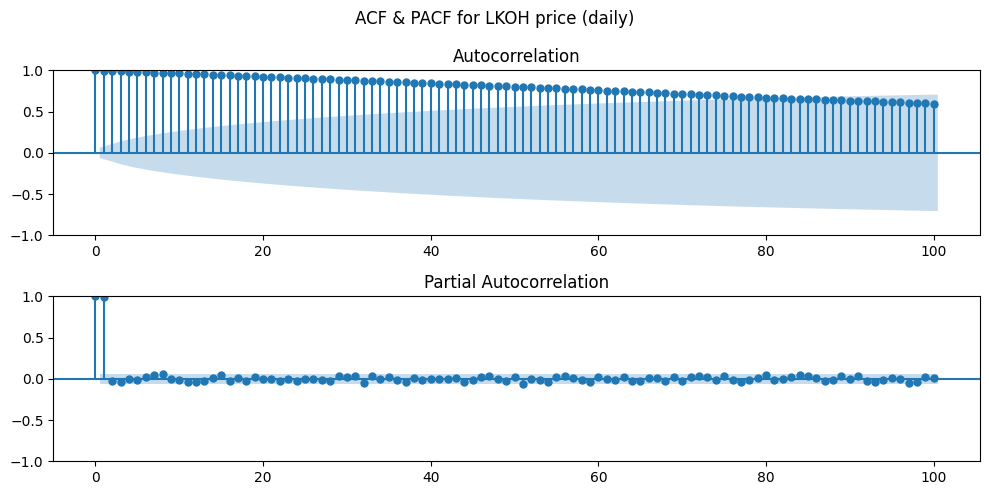

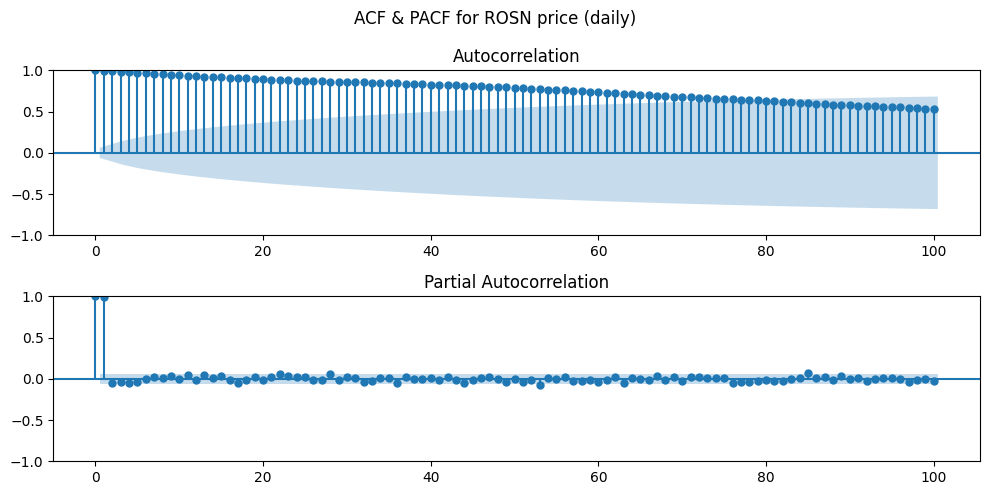

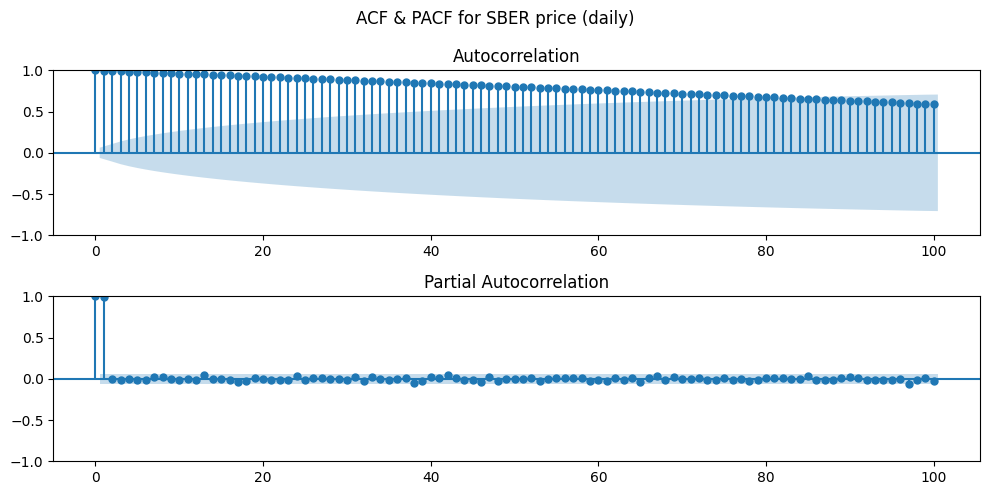

In [19]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


for ticker, df in stocks_data_daily.items():
    fig, ax = plt.subplots(2, 1, figsize=(10, 5))
    fig.suptitle(f'ACF & PACF for {ticker} price (daily)')
    plot_acf(df['close'], lags=100, ax=ax[0])
    plot_pacf(df['close'], lags=100, ax=ax[1])
    plt.tight_layout()
    plt.show()

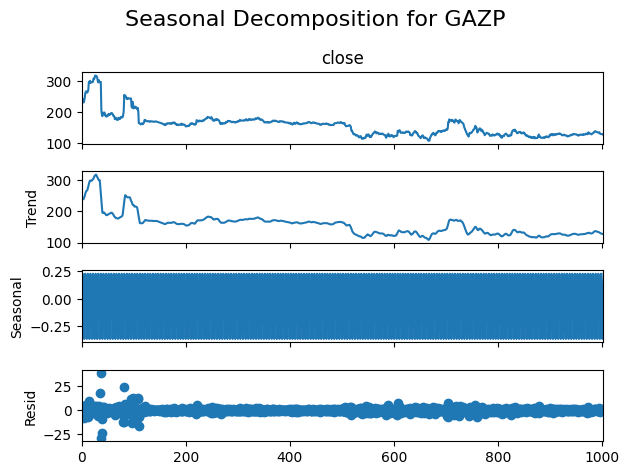

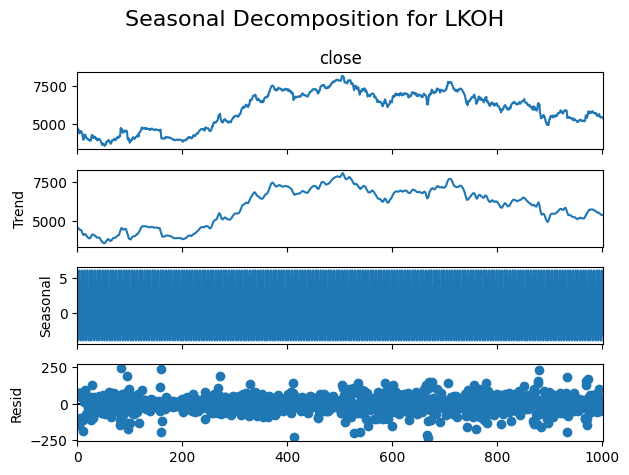

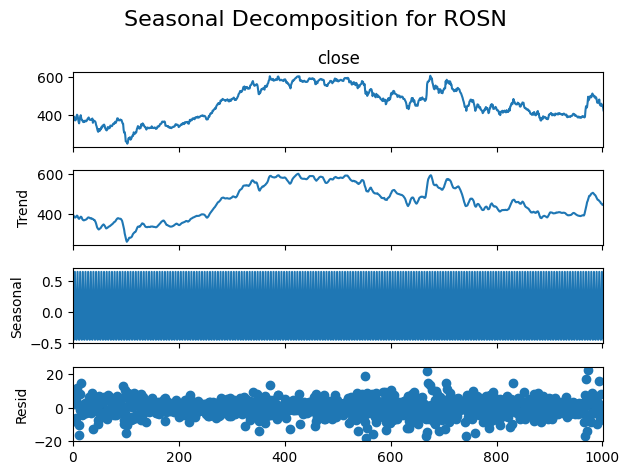

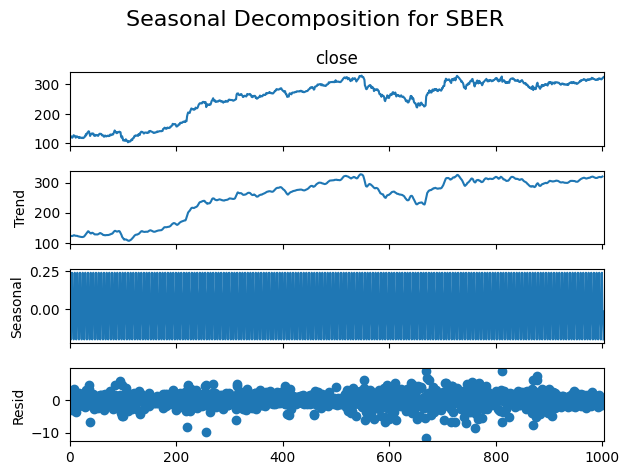

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

for ticker, df in stocks_data_daily.items():
    res = seasonal_decompose(df['close'], period=5, model='additive')
    fig = res.plot()
    fig.suptitle(f"Seasonal Decomposition for {ticker}", fontsize=16)
    plt.tight_layout()
    plt.show()

In [21]:
stocks_data_1w_daily_df = pd.concat(stocks_data_daily.values(), keys=stocks_data_daily.keys()).reset_index(level=0).rename(columns={'level_0': 'company'})

In [22]:
fig = go.Figure()

for ticker in stocks_data_1w_daily_df['company'].unique():
    df = stocks_data_1w_daily_df[stocks_data_1w_daily_df['company'] == ticker]
    fig.add_trace(
        go.Scatter(
            x=df['begin'],
            y=df['close'],
            mode="lines",
            name=ticker
        )
    )

fig.update_layout(
    title="Stock Prices (Daily)",
    xaxis_title="Date",
    yaxis_title="Price",
    template="plotly_white"
)
fig.show()

In [23]:
# Log scale

fig = go.Figure()

for ticker in stocks_data_1w_daily_df['company'].unique():
    df = stocks_data_1w_daily_df[stocks_data_1w_daily_df['company'] == ticker]
    fig.add_trace(
        go.Scatter(
            x=df['begin'],
            y=np.log(df['close']),
            mode="lines",
            name=ticker
        )
    )

fig.update_layout(
    title="Stock Prices (Daily, Log Scale)",
    xaxis_title="Date",
    yaxis_title="Log(Price)",
    template="plotly_white"
)
fig.show()

Итоги исследования цены акций:
- Сезонность присутствует, но почти незаметная
- График ACF медленно падает. Есть тренд.
- На графике PACF все значения, кроме 1, находятся около "синей зоны".

Получается, что есть зависимость между многими предыдущими значениями, но прямых зависимостей нет.

Модели сложно будет адекватно предсказать такое. Попробуем взять что-нибудь другое в качестве target.

### 1.4. Анализ доходности

Попробуем взять не цену акций, а доходность акции, если купим сегодня, а продадим через неделю.

Возьмем log доходность:
$$
r_{t} = \log(P_{t}) - \log(P_{t-1})
$$

In [24]:
# Посчитаем log доходность для всех акций

stocks_returns_daily = {}

for ticker, df in stocks_data_daily.items():
    df = df.copy()
    df['target_log_return_5d'] = forward_log_return(df['close'], periods=5)
    df['target_log_return_1d'] = forward_log_return(df['close'], periods=1)
    stocks_returns_daily[ticker] = df.dropna().reset_index(drop=True)

display(stocks_returns_daily['GAZP'].tail(10))
stocks_returns_daily['GAZP'].shape

,begin,open,close,high,low,value,volume,end,ticker,target_log_return_5d,target_log_return_1d
988,2026-03-30,135.85,136.20,136.52,135.82,320744999.2,2355030.0,2026-03-30 18:59:59,GAZP,-0.020622,-0.013453
989,2026-03-31,133.93,134.38,134.70,133.93,567503852.2,4225120.0,2026-03-31 18:59:59,GAZP,-0.001042,0.000521
990,2026-04-01,134.21,134.45,134.75,134.10,231130456.8,1718640.0,2026-04-01 18:59:59,GAZP,-0.027523,-0.005594
991,2026-04-02,133.37,133.70,133.81,133.30,200366111.1,1500360.0,2026-04-02 18:59:59,GAZP,-0.039436,-0.004723
992,2026-04-03,133.19,133.07,133.28,132.98,149489530.0,1122510.0,2026-04-03 18:58:08,GAZP,-0.034013,0.002627
993,2026-04-06,133.82,133.42,134.00,133.34,748072971.1,5600360.0,2026-04-06 18:59:59,GAZP,-0.038196,0.006127
994,2026-04-07,134.61,134.24,134.70,134.24,159354120.1,1185470.0,2026-04-07 18:59:59,GAZP,-0.046116,-0.025960
995,2026-04-08,130.74,130.80,131.14,130.70,439706952.0,3358600.0,2026-04-08 18:59:07,GAZP,-0.017896,-0.017507
996,2026-04-09,128.71,128.53,128.82,128.38,758460846.3,5896330.0,2026-04-09 18:59:59,GAZP,-0.005774,0.000700
997,2026-04-10,128.54,128.62,129.26,128.32,371459522.0,2887170.0,2026-04-10 18:59:59,GAZP,-0.031353,-0.001556


(998, 11)

In [25]:
# График log доходности, рядом с графиком цены

from plotly.subplots import make_subplots

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(
    go.Scatter(x=stocks_returns_daily['GAZP'].index, y=stocks_returns_daily['GAZP']['close'], name="price"),
    secondary_y=False,
)

fig.add_trace(
    go.Scatter(x=stocks_returns_daily['GAZP'].index, y=stocks_returns_daily['GAZP']['target_log_return_5d'], name="log return 5 days"),
    secondary_y=True,
)

fig.add_trace(
    go.Scatter(x=stocks_returns_daily['GAZP'].index, y=stocks_returns_daily['GAZP']['target_log_return_1d'], name="log return 1 day"),
    secondary_y=True,
)


# Add figure title
fig.update_layout(
    title_text="GAZP: Price and Log Return After 1 Week"
)

fig.update_xaxes(title_text="Date")

fig.update_yaxes(title_text="price", secondary_y=False)
fig.update_yaxes(title_text="log return", secondary_y=True)

fig.show()

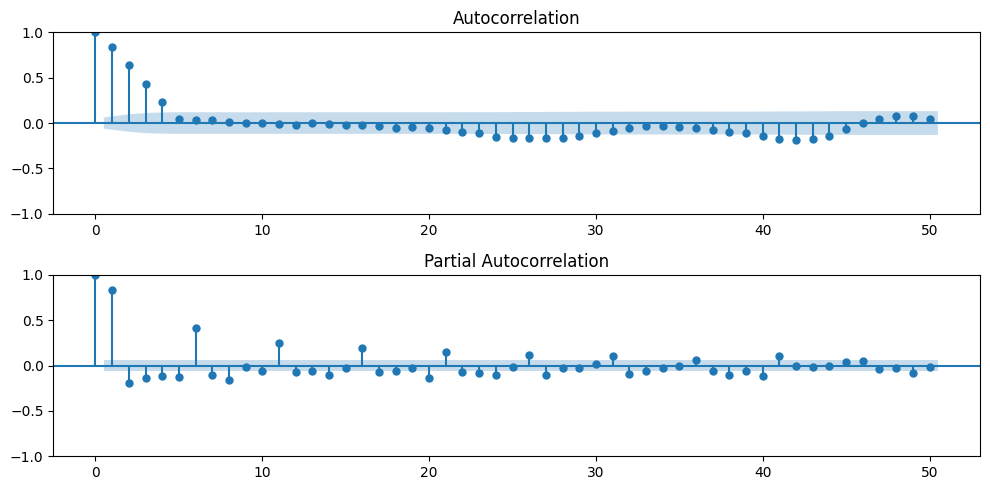

In [26]:
# Проанализируем

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
plot_acf(stocks_returns_daily['GAZP']['target_log_return_5d'], lags=50, ax=ax[0]);
plot_pacf(stocks_returns_daily['GAZP']['target_log_return_5d'], lags=50, ax=ax[1]);
plt.tight_layout()
plt.show()

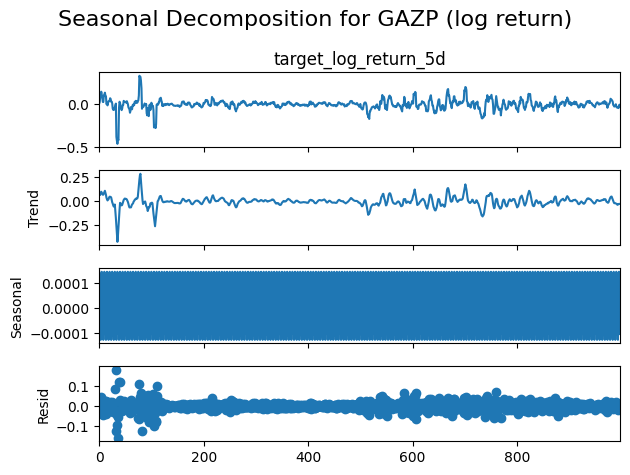

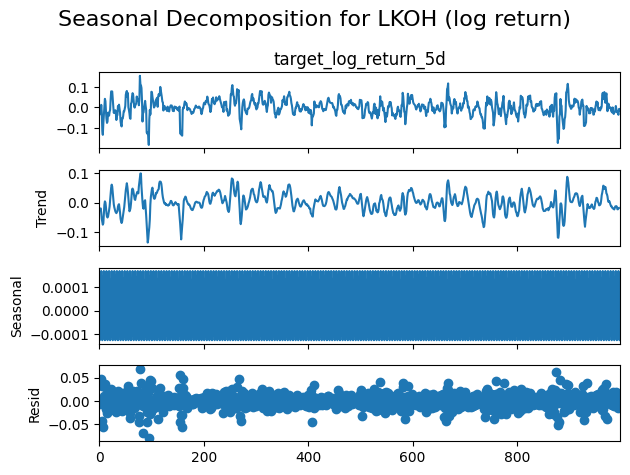

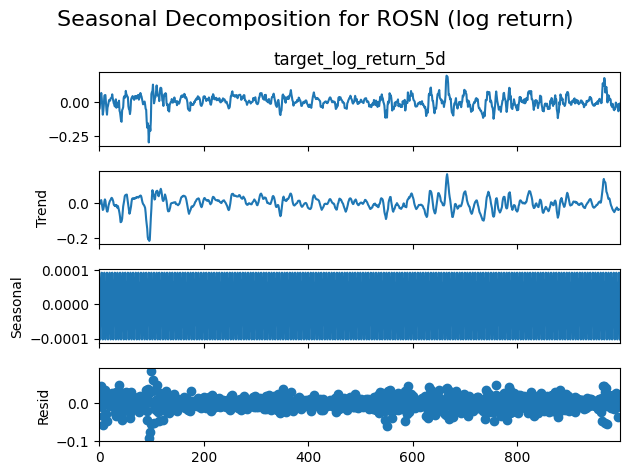

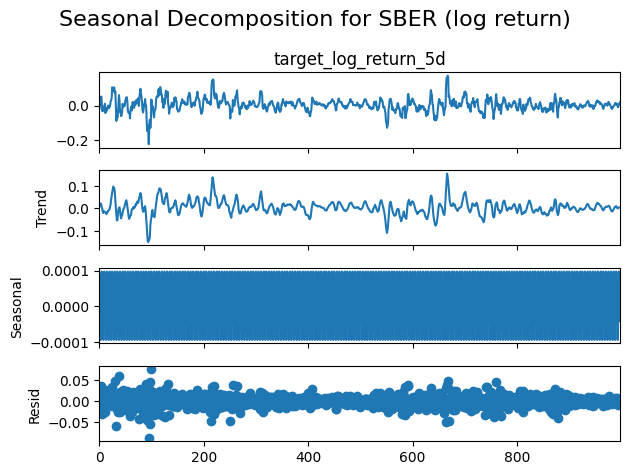

In [27]:
for ticker, df in stocks_returns_daily.items():
    res = seasonal_decompose(df['target_log_return_5d'], period=5, model='additive')
    fig = res.plot()
    fig.suptitle(f"Seasonal Decomposition for {ticker} (log return)", fontsize=16)
    plt.tight_layout()
    plt.show()

Здесь мы уже видим кое что интересное.

ACF быстро затухает, за 6 дней.

А на PACF наблюдаем всплески, которые происходят примерно каждые 7 дней.

Стоит попробовать модель `AR(2)`.

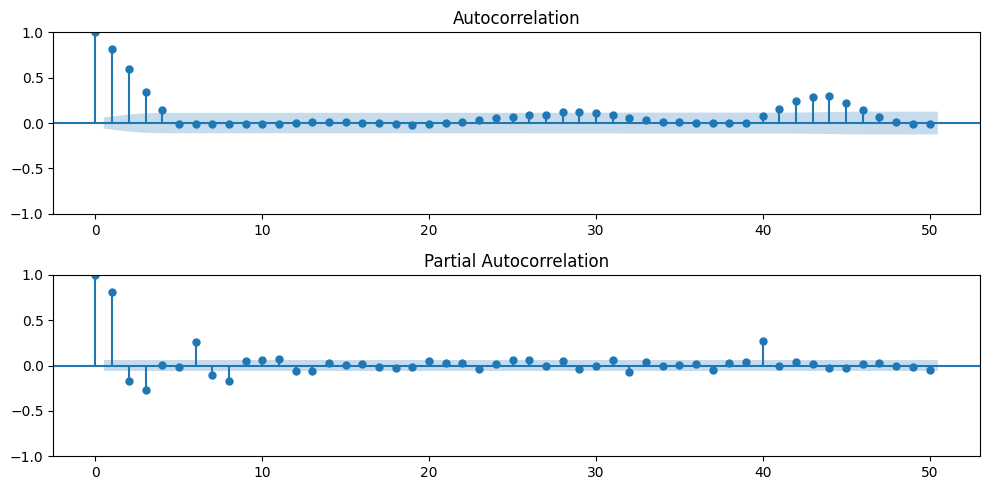

In [28]:
# Попробуем квадраты

fig, ax = plt.subplots(2, 1, figsize=(10, 5))
plot_acf(stocks_returns_daily['GAZP']['target_log_return_5d'] ** 2, lags=50, ax=ax[0]);
plot_pacf(stocks_returns_daily['GAZP']['target_log_return_5d'] ** 2, lags=50, ax=ax[1]);
plt.tight_layout()
plt.show()

### 1.4. Пробуем SARIMA модель

Будем предсказывать Log-доходность за 1 день: предсказываем за 5 дней, суммируем и находим реальную цену.

$$
\begin{align}
&r_{t} = \log(P_{t}) - \log(P_{t-1}) \\
&S_{t,t+5} = \sum_{i=1}^5 r_i \\
&P_{t+5} = P_{t} \cdot e^{S_{t,t+5}}
\end{align}
$$


In [29]:
from typing import Protocol


# Интерфейс модели
class ForecastModel(Protocol):
    def train(self, train_df: pd.DataFrame) -> "ForecastModel":
        ...

    def predict(self, test_df: pd.DataFrame) -> pd.Series:
        ...

In [30]:
from sklearn.model_selection import TimeSeriesSplit

HORIZON = 5

# Делим выборку на train/test
# Таргет - стоимость через 5 дней, поэтому делаем gap=5
# Для теста используем 20 следующих после gap дней
tscv_5d = TimeSeriesSplit(test_size=20, n_splits=20, gap=5)
tscv_1d = TimeSeriesSplit(test_size=20, n_splits=20, gap=1)

In [31]:
# Тикер -> модель -> метрики
results = {
    'GAZP': {},
    'LKOH': {},
    'ROSN': {},
    'SBER': {},
}

In [32]:
def aggregate_predictions(y_true_oof, y_pred_oof, fold_metrics):
    oof_mse = mean_squared_error(y_true_oof, y_pred_oof)
    oof_rmse = np.sqrt(oof_mse)
    oof_r2 = r2_score(y_true_oof, y_pred_oof)

    return {
        "oof_mse": float(oof_mse),
        "oof_rmse": float(oof_rmse),
        "oof_r2": float(oof_r2),

        "fold_mse_mean": float(np.mean([m["mse"] for m in fold_metrics])),
        "fold_mse_median": float(np.median([m["mse"] for m in fold_metrics])),
        "fold_mse_std": float(np.std([m["mse"] for m in fold_metrics])),

        "fold_rmse_mean": float(np.mean([m["rmse"] for m in fold_metrics])),
        "fold_rmse_median": float(np.median([m["rmse"] for m in fold_metrics])),
        "fold_rmse_std": float(np.std([m["rmse"] for m in fold_metrics])),

        "fold_r2_mean": float(np.mean([m["r2"] for m in fold_metrics])),
        "fold_r2_median": float(np.median([m["r2"] for m in fold_metrics])),
        "fold_r2_std": float(np.std([m["r2"] for m in fold_metrics])),
    }

In [33]:
def build_prediction_frame(
    test_df: pd.DataFrame,
    pred_log_return: pd.Series | np.ndarray,
    *,
    target_col: str = "target_log_return_5d",
    price_col: str = "close",
    date_col: str = "begin",
) -> pd.DataFrame:
    pred_log_return = pd.Series(pred_log_return, index=test_df.index, name="pred_log_return")

    out = test_df[[date_col, price_col, target_col]].copy()
    out["pred_log_return"] = pred_log_return

    out["actual_future_price"] = inverse_log_return(
        out[target_col],
        out[price_col],
    )

    out["pred_future_price"] = inverse_log_return(
        out["pred_log_return"],
        out[price_col],
    )

    return out

In [118]:
from dataclasses import dataclass
from typing import Any


@dataclass
class FoldResult:
    fold_number: int
    train_start: Any
    train_end: Any
    test_start: Any
    test_end: Any
    predictions: pd.DataFrame


def evaluate_one_fold(
    model: ForecastModel,
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    *,
    fold_number: int,
    target_col: str = "target_log_return_5d",
    price_col: str = "close",
    date_col: str = "begin",
) -> FoldResult:
    model.train(train_df)
    pred_log_return = model.predict(test_df)

    pred_df = build_prediction_frame(
        test_df=test_df,
        pred_log_return=pred_log_return,
        target_col=target_col,
        price_col=price_col,
        date_col=date_col,
    )

    return FoldResult(
        fold_number=fold_number,
        train_start=train_df[date_col].iloc[0],
        train_end=train_df[date_col].iloc[-1],
        test_start=test_df[date_col].iloc[0],
        test_end=test_df[date_col].iloc[-1],
        predictions=pred_df,
    )

def calculate_metrics_for_all_folds(
    folds: list[FoldResult],
    target_log_return_col: str = "target_log_return_5d",
    pred_log_return_col: str = "pred_log_return",
    actual_future_price_col: str = "actual_future_price",
    pred_future_price_col: str = "pred_future_price",
    ) -> dict[str, Any]:
    all_predictions = pd.concat(
        [fold.predictions.assign(fold_number=fold.fold_number) for fold in folds],
        ignore_index=True,
    )

    y_true_return = all_predictions[target_log_return_col].to_numpy(dtype=float)
    y_pred_return = all_predictions[pred_log_return_col].to_numpy(dtype=float)

    y_true_price = all_predictions[actual_future_price_col].to_numpy(dtype=float)
    y_pred_price = all_predictions[pred_future_price_col].to_numpy(dtype=float)

    finite = (
        np.isfinite(y_true_return)
        & np.isfinite(y_pred_return)
        & np.isfinite(y_true_price)
        & np.isfinite(y_pred_price)
    )
    if not np.any(finite):
        raise ValueError("No finite rows left for metrics (all NaN/inf).")
    y_true_return = y_true_return[finite]
    y_pred_return = y_pred_return[finite]
    y_true_price = y_true_price[finite]
    y_pred_price = y_pred_price[finite]

    return_mae = mean_absolute_error(y_true_return, y_pred_return)
    price_mae = mean_absolute_error(y_true_price, y_pred_price)

    return_mse = mean_squared_error(y_true_return, y_pred_return)
    price_mse = mean_squared_error(y_true_price, y_pred_price)

    # r2_score may be undefined if target is constant
    return_r2 = np.nan if np.allclose(y_true_return, y_true_return[0]) else r2_score(y_true_return, y_pred_return)
    price_r2 = np.nan if np.allclose(y_true_price, y_true_price[0]) else r2_score(y_true_price, y_pred_price)

    return {
        "n_folds": len(folds),
        "n_oof_predictions": int(len(y_true_return)),

        "return_mae": float(return_mae),
        "return_rmse": float(np.sqrt(return_mse)),
        "return_r2": float(return_r2) if not np.isnan(return_r2) else np.nan,

        "price_mae": float(price_mae),
        "price_rmse": float(np.sqrt(price_mse)),
        "price_r2": float(price_r2) if not np.isnan(price_r2) else np.nan,
    }

In [119]:
from typing import Callable


def run_cv_backtest(
    model_factory: Callable[[], ForecastModel],
    df: pd.DataFrame,
    splitter,
    *,
    target_col: str = "target_log_return_5d",
    price_col: str = "close",
    date_col: str = "begin",
    verbose: bool = True,
) -> dict[str, Any]:
    fold_results: list[FoldResult] = []

    for fold_number, (train_index, test_index) in tqdm(enumerate(splitter.split(df), start=1), position=2, leave=False):
        train_df = df.iloc[train_index].copy()
        test_df = df.iloc[test_index].copy()

        model = model_factory()

        fold_result = evaluate_one_fold(
            model=model,
            train_df=train_df,
            test_df=test_df,
            fold_number=fold_number,
            target_col=target_col,
            price_col=price_col,
            date_col=date_col,
        )
        fold_results.append(fold_result)

        if verbose:
            print(f"Fold {fold_number}:")
            print(f"  Train: {fold_result.train_start} - {fold_result.train_end} ({len(train_df)} rows)")
            print(f"  Test : {fold_result.test_start} - {fold_result.test_end} ({len(test_df)} rows)")
            print()

    all_predictions = pd.concat([fr.predictions.assign(fold=fr.fold_number) for fr in fold_results], axis=0)

    return {
        "fold_results": fold_results,
        "predictions": all_predictions,
    }

In [36]:
class ZeroReturnBaseline():
    def __init__(self, target_col: str = "target_log_return_5d"):
        self.target_col = target_col

    def train(self, train_df: pd.DataFrame):
        return self

    def predict(self, test_df: pd.DataFrame) -> pd.Series:
        return pd.Series(
            data=np.zeros(len(test_df), dtype=float),
            index=test_df.index,
            name="pred_log_return",
        )

In [92]:
def run_and_calculate_metrics(df_by_ticker, model_factory, verbose=False):
    out = {}
    for ticker, df in tqdm(df_by_ticker.items(), position=0, desc='Tickers'):
        print(f"{ticker}: {df['begin'].min()} - {df['begin'].max()} ({len(df)} rows)")

        cv_result = run_cv_backtest(
            model_factory=model_factory,
            df=df,
            splitter=tscv_5d,
            target_col="target_log_return_5d",
            price_col="close",
            date_col="begin",
            verbose=verbose,
        )

        out[ticker] = calculate_metrics_for_all_folds(cv_result["fold_results"])
    return out

In [38]:
for ticker, metrics in run_and_calculate_metrics(
    stocks_returns_daily,
    lambda: ZeroReturnBaseline(target_col="target_log_return_5d"),
).items():
    results[ticker]["baseline"] = metrics

  0%|          | 0/4 [00:00<?, ?it/s]

GAZP: 2022-05-04 00:00:00 - 2026-04-10 00:00:00 (998 rows)


0it [00:00, ?it/s]

LKOH: 2022-05-04 00:00:00 - 2026-04-10 00:00:00 (998 rows)


0it [00:00, ?it/s]

ROSN: 2022-05-04 00:00:00 - 2026-04-10 00:00:00 (998 rows)


0it [00:00, ?it/s]

SBER: 2022-05-04 00:00:00 - 2026-04-10 00:00:00 (998 rows)


0it [00:00, ?it/s]

In [39]:
# Теперь SARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX


class SarimaxDirectModel:
    def __init__(
        self,
        exog_cols: list[str] = None,
        target_col: str = "target_log_return_5d",
        order=(1, 0, 0),
        seasonal_order=(0, 0, 0, 0),
        method='lbfgs',
    ):
        self.exog_cols = exog_cols or []
        self.target_col = target_col
        self.order = order
        self.seasonal_order = seasonal_order
        self.method = method
        self.fitted = None

    def train(self, train_df: pd.DataFrame):
        y_train = train_df[self.target_col]
        X_train = train_df[self.exog_cols] if self.exog_cols else None

        model = SARIMAX(
            endog=y_train,
            exog=X_train,
            order=self.order,
            seasonal_order=self.seasonal_order,
            trend="c",
            enforce_stationarity=True,
            enforce_invertibility=True,
        )
        self.fitted = model.fit(disp=False, method=self.method)
        return self

    def predict(self, test_df: pd.DataFrame) -> pd.Series:
        if self.fitted is None:
            raise RuntimeError("Call train before predict")

        X_test = test_df[self.exog_cols] if self.exog_cols else None
        fc = (
            self.fitted.get_forecast(steps=len(test_df), exog=X_test)
            if X_test is not None
            else self.fitted.get_forecast(steps=len(test_df))
        )
        pred = fc.predicted_mean

        return pd.Series(pred, index=test_df.index, name="pred_log_return")

In [40]:
for order in [(1, 0, 0), (2, 0, 0), (1, 0, 1)]:
    key = f"SARIMA({', '.join(map(str, order))})"
    for ticker, metrics in run_and_calculate_metrics(
        stocks_returns_daily,
        lambda o=order: SarimaxDirectModel(
            target_col="target_log_return_5d",
            order=o,
        ),
    ).items():
        results[ticker][key] = metrics

  0%|          | 0/4 [00:00<?, ?it/s]

GAZP: 2022-05-04 00:00:00 - 2026-04-10 00:00:00 (998 rows)


0it [00:00, ?it/s]

/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



LKOH: 2022-05-04 00:00:00 - 2026-04-10 00:00:00 (998 rows)


...

ROSN: 2022-05-04 00:00:00 - 2026-04-10 00:00:00 (998 rows)


0it [00:00, ?it/s]

SBER: 2022-05-04 00:00:00 - 2026-04-10 00:00:00 (998 rows)


0it [00:00, ?it/s]

/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [41]:
def results_as_table(results):
    rows = []
    for ticker, models in results.items():
        for model_name, metrics in models.items():
            row = {
                'Ticker': ticker,
                'Model': model_name,
                'Folds': metrics['n_folds'],
                'Predictions': metrics['n_oof_predictions'],
                'Return MAE': metrics['return_mae'],
                'Return RMSE': metrics['return_rmse'],
                'Return R2': metrics['return_r2'],
                'Price MAE': metrics['price_mae'],
                'Price RMSE': metrics['price_rmse'],
                'Price R2': metrics['price_r2'],
            }
            rows.append(row)
    return pd.DataFrame(rows).sort_values(['Ticker', 'Price R2'], ascending=(True, False))

In [42]:
results_as_table(results)

,Ticker,Model,Folds,Predictions,Return MAE,Return RMSE,Return R2,Price MAE,Price RMSE,Price R2
2,GAZP,"SARIMA(2, 0, 0)",20,300,0.041448,0.057052,-0.028691,5.500636,7.734976,0.690344
3,GAZP,"SARIMA(1, 0, 1)",20,300,0.041518,0.057194,-0.033816,5.510175,7.751871,0.688990
0,GAZP,baseline,20,400,0.040104,0.055169,-0.000141,5.327550,7.492638,0.686761
1,GAZP,"SARIMA(1, 0, 0)",20,300,0.041889,0.057615,-0.049112,5.559572,7.802746,0.684894
6,LKOH,"SARIMA(2, 0, 0)",20,300,0.028006,0.038561,-0.023917,174.535351,237.168492,0.883552
7,LKOH,"SARIMA(1, 0, 1)",20,300,0.028068,0.038662,-0.029290,174.922095,237.682913,0.883046
5,LKOH,"SARIMA(1, 0, 0)",20,300,0.028243,0.038855,-0.039545,175.985892,238.676715,0.882066
4,LKOH,baseline,20,400,0.027793,0.038068,-0.004499,173.241250,234.755166,0.882005
8,ROSN,baseline,20,400,0.036170,0.048691,-0.000838,16.864500,23.095790,0.810493
10,ROSN,"SARIMA(2, 0, 0)",20,300,0.037439,0.050035,-0.012288,17.438074,23.727882,0.809095


Модель SARIMA справилась примерно на уровне наивного бэйзлайна


### 1.5. Дополнительные признаки

Попробуем добавить признаки к SARIMAX модели. Сначала спарсим и обработаем их.

In [73]:
# Спарсим золото

gold_data = await moex_client.get_data(
    tickers=['GLDRUB_TOM'],
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    start_date=date_start,
    end_date=datetime.now(),
    interval=Interval.HOUR_1,
)
gold_df = gold_data['GLDRUB_TOM'].copy()
gold_df.tail(10)

,open,close,high,low,value,volume,begin,end,ticker
11310,11674.4,11674.4,11674.4,11674.4,1587718.4,136,2026-04-17 09:00:00,2026-04-17 09:59:59,GLDRUB_TOM
11311,11670.0,11655.0,11684.6,11632.1,413085905.3,35426,2026-04-17 10:00:00,2026-04-17 10:59:59,GLDRUB_TOM
11312,11658.0,11702.8,11709.5,11658.0,544379239.8,46551,2026-04-17 11:00:00,2026-04-17 11:59:59,GLDRUB_TOM
11313,11696.0,11685.0,11715.0,11649.1,465268345.8,39831,2026-04-17 12:00:00,2026-04-17 12:59:59,GLDRUB_TOM
11314,11686.0,11670.5,11693.0,11662.4,205121998.6,17561,2026-04-17 13:00:00,2026-04-17 13:59:59,GLDRUB_TOM
11315,11674.1,11702.0,11717.2,11661.8,457488992.4,39077,2026-04-17 14:00:00,2026-04-17 14:59:59,GLDRUB_TOM
11316,11702.0,11789.2,11797.0,11700.1,204392514.0,17398,2026-04-17 15:00:00,2026-04-17 15:59:59,GLDRUB_TOM
11317,11791.4,11826.0,11876.0,11757.7,716078449.3,60551,2026-04-17 16:00:00,2026-04-17 16:59:59,GLDRUB_TOM
11318,11830.0,11838.8,11862.8,11788.4,562320425.4,47539,2026-04-17 17:00:00,2026-04-17 17:59:59,GLDRUB_TOM
11319,11838.8,11819.0,11840.0,11803.0,156561831.7,13243,2026-04-17 18:00:00,2026-04-17 18:59:59,GLDRUB_TOM


In [44]:
# Валюты

currencies_prices = await moex_client.get_data(
    tickers=['USDRUBF', 'EURRUBF', 'CNYRUBF'],
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    start_date=date_start,
    end_date=datetime.now(),
    interval=Interval.HOUR_1,
)
currencies_prices

{'USDRUBF':         open  close   high    low  value  volume               begin  \
 0      71.87  72.00  72.88  70.27      0    1735 2022-05-04 10:00:00   
 1      71.91  70.62  71.94  70.43      0    1280 2022-05-04 11:00:00   
 2      70.59  70.27  70.70  70.10      0    1167 2022-05-04 12:00:00   
 3      70.29  70.27  70.57  70.12      0     453 2022-05-04 13:00:00   
 4      70.27  70.55  70.71  70.27      0     426 2022-05-04 14:00:00   
 ...      ...    ...    ...    ...    ...     ...                 ...   
 15198  75.90  75.88  75.98  75.85      0    3234 2026-04-17 19:00:00   
 15199  75.89  75.89  75.91  75.85      0    2367 2026-04-17 20:00:00   
 15200  75.90  76.00  76.05  75.89      0    8954 2026-04-17 21:00:00   
 15201  76.02  76.01  76.09  75.97      0    4379 2026-04-17 22:00:00   
 15202  76.00  76.06  76.07  75.95      0    1743 2026-04-17 23:00:00   
 
                       end   ticker  
 0     2022-05-04 10:59:59  USDRUBF  
 1     2022-05-04 11:59:59  USDRUBF

In [45]:
imoex_data = await moex_client.get_data(
    tickers=['IMOEX'],
    engine=Engines.STOCK,
    market=Markets.INDEX,
    board=Boards.RFUD,
    start_date=date_start,
    end_date=datetime.now(),
    interval=Interval.HOUR_1,
)
imoex_df = imoex_data['IMOEX'].copy()
imoex_df.tail(10)

,open,close,high,low,value,volume,begin,end,ticker
9354,2741.81,2740.61,2742.95,2738.69,7.701295e+08,0,2026-04-17 09:00:00,2026-04-17 09:59:59,IMOEX
9355,2740.62,2749.67,2750.35,2736.48,7.327749e+09,0,2026-04-17 10:00:00,2026-04-17 10:59:59,IMOEX
9356,2749.73,2744.56,2753.21,2744.47,4.324574e+09,0,2026-04-17 11:00:00,2026-04-17 11:59:59,IMOEX
9357,2744.54,2743.02,2745.09,2740.15,3.045968e+09,0,2026-04-17 12:00:00,2026-04-17 12:59:59,IMOEX
9358,2743.01,2743.05,2746.11,2740.86,2.879695e+09,0,2026-04-17 13:00:00,2026-04-17 13:59:59,IMOEX
9359,2743.09,2752.82,2754.50,2742.68,4.100629e+09,0,2026-04-17 14:00:00,2026-04-17 14:59:59,IMOEX
9360,2752.82,2745.10,2758.66,2743.28,8.229906e+09,0,2026-04-17 15:00:00,2026-04-17 15:59:59,IMOEX
9361,2745.10,2724.59,2745.72,2718.59,1.873658e+10,0,2026-04-17 16:00:00,2026-04-17 16:59:59,IMOEX
9362,2724.59,2720.40,2725.19,2716.80,1.100994e+10,0,2026-04-17 17:00:00,2026-04-17 17:59:59,IMOEX
9363,2720.46,2723.94,2726.60,2718.39,8.318904e+09,0,2026-04-17 18:00:00,2026-04-17 18:59:59,IMOEX


In [46]:
# Нефть
# С ней немного поколдуем. Вечного фьючерса нет, поэтому придётся склеить несколько фьючерсов вместе.
# Код взял из parsing_currencies_n_metals.ipynb

import aiohttp


def generate_all_brent_tickers(start_year=2022, end_year=2026):
    month_codes = {
        1: 'F', 2: 'G', 3: 'H', 4: 'J', 5: 'K', 6: 'M',
        7: 'N', 8: 'Q', 9: 'U', 10: 'V', 11: 'X', 12: 'Z'
    }
    year_codes = {2022: '2', 2023: '3', 2024: '4', 2025: '5', 2026: '6', 2027: '7'}
    
    tickers = []
    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            ticker = f"BR{month_codes[month]}{year_codes[year]}"
            expiry_date = pd.Timestamp(year=year, month=month, day=1)
            tickers.append({'ticker': ticker, 'expiry': expiry_date})
    
    return pd.DataFrame(tickers)


async def get_brent_futures_metadata():
    url = "https://iss.moex.com/iss/engines/futures/markets/forts/boards/RFUD/securities.json"
    async with aiohttp.ClientSession() as session:
        async with session.get(url) as response:
            data = await response.json()
    
    securities = data['securities']
    df_active = pd.DataFrame(securities['data'], columns=securities['columns'])
    df_active = df_active[df_active['SECID'].str.startswith('BR') & ~df_active['SECID'].str.startswith('BRM')]
    df_active['LASTTRADEDATE'] = pd.to_datetime(df_active['LASTTRADEDATE'])
    df_active = df_active[['SECID', 'LASTTRADEDATE']].rename(columns={'SECID': 'ticker', 'LASTTRADEDATE': 'expiry'})
    df_active = df_active.dropna()
    
    df_all = generate_all_brent_tickers(2022, 2027)
    
    for idx, row in df_active.iterrows():
        mask = df_all['ticker'] == row['ticker']
        if mask.any():
            df_all.loc[mask, 'expiry'] = row['expiry']
    
    return df_all.sort_values('expiry').reset_index(drop=True)

In [47]:
futures_meta = await get_brent_futures_metadata()

tickers = futures_meta['ticker'].tolist()

brent_data = await moex_client.get_data(
    tickers=tickers,
    engine=Engines.FUTURES,
    market=Markets.FORTS,
    board=Boards.RFUD,
    start_date=date_start,
    end_date=datetime.now(),
    interval=Interval.HOUR_1,
)
brent_data.keys()

dict_keys(['BRF2', 'BRG2', 'BRH2', 'BRJ2', 'BRK2', 'BRM2', 'BRN2', 'BRQ2', 'BRU2', 'BRV2', 'BRX2', 'BRZ2', 'BRF3', 'BRG3', 'BRH3', 'BRJ3', 'BRK3', 'BRM3', 'BRN3', 'BRQ3', 'BRU3', 'BRV3', 'BRX3', 'BRZ3', 'BRF4', 'BRG4', 'BRH4', 'BRJ4', 'BRK4', 'BRM4', 'BRN4', 'BRQ4', 'BRU4', 'BRV4', 'BRX4', 'BRZ4', 'BRF5', 'BRG5', 'BRH5', 'BRJ5', 'BRK5', 'BRM5', 'BRN5', 'BRQ5', 'BRU5', 'BRV5', 'BRX5', 'BRZ5', 'BRF6', 'BRG6', 'BRH6', 'BRJ6', 'BRK6', 'BRM6', 'BRN6', 'BRQ6', 'BRU6', 'BRV6', 'BRX6', 'BRZ6', 'BRF7', 'BRG7', 'BRH7', 'BRJ7', 'BRK7', 'BRM7', 'BRN7', 'BRQ7', 'BRU7', 'BRV7', 'BRX7', 'BRZ7'])

In [48]:
from datetime import timedelta


def count_trading_days(start_date, end_date):
    if pd.isna(start_date) or pd.isna(end_date):
        return 0
    if isinstance(start_date, pd.Timestamp):
        start_date = start_date.date()
    if isinstance(end_date, pd.Timestamp):
        end_date = end_date.date()
    
    trading_days = 0
    current = start_date
    while current < end_date:
        if current.weekday() < 5:
            trading_days += 1
        current += timedelta(days=1)
    return trading_days


def select_contract(timestamp_t, futures_meta, all_data, roll_window=5):
    """
    Select the nearest-expiring futures contract for a given timestamp,
    subject to a minimum roll window in trading days.

    Parameters
    ----------
    timestamp_t : datetime-like
        The timestamp at which we want a contract (e.g. bar time).
    futures_meta : pd.DataFrame
        Must contain columns:
            - 'ticker' : str
            - 'expiry' : datetime64[ns] or convertible to datetime
        One row per contract.
    all_data : dict[str, pd.DataFrame]
        Mapping from ticker -> DataFrame with at least:
            - 'begin' : datetime64[ns] (bar start time)
    roll_window : int
        Minimum number of trading days to expiry to allow using this contract.

    Returns
    -------
    str | None
        Selected contract ticker, or None if no suitable contract has data
        at the given timestamp.
    """

    # Normalize timestamp
    timestamp_t = pd.Timestamp(timestamp_t)

    # Work in date space for roll logic
    date_t = timestamp_t.date()
    # Don't include contracts that expire more than 3 months from now
    date_t_max = date_t + timedelta(days=90)

    # Ensure expiry is proper datetime64[ns]
    futures_meta = futures_meta.copy()
    futures_meta['expiry'] = pd.to_datetime(futures_meta['expiry'])

    # Convert date_t and date_t_max to Timestamp so types match expiry (datetime64[ns])
    start_ts = pd.to_datetime(date_t)       # midnight of current date
    end_ts = pd.to_datetime(date_t_max)     # midnight of max date

    # Contracts whose expiry is strictly after current date and before date_t_max
    available = futures_meta.loc[
        (futures_meta['expiry'] > start_ts) &
        (futures_meta['expiry'] < end_ts)
    ].copy()

    if available.empty:
        return None

    # Compute days to expiry for each contract using trading days
    # Here we go back to pure `date` for count_trading_days
    available['days_to_expiry'] = available['expiry'].dt.date.apply(
        lambda d: count_trading_days(date_t, d)
    )

    # Keep only contracts that satisfy the roll_window constraint
    candidates = available.loc[available['days_to_expiry'] >= roll_window]
    if candidates.empty:
        return None

    # Sort so the nearest expiry (smallest days_to_expiry) is considered first
    candidates = candidates.sort_values(['days_to_expiry', 'expiry'])

    def has_bar_at_timestamp(ticker: str) -> bool:
        """Check that the given contract has data at timestamp_t."""
        df = all_data.get(ticker)
        if df is None or df.empty:
            return False
        return not df.loc[df['begin'] == timestamp_t].empty

    # Choose the nearest-expiring candidate that actually has a bar at this time
    for ticker in candidates['ticker']:
        if has_bar_at_timestamp(ticker):
            return ticker

    # No candidate contract had data at this timestamp
    return None



async def build_brent_continuous(start_date, end_date, all_data, futures_meta, roll_window=5):
    print(f"\nBuilding continuous series (roll_window={roll_window})...")
    all_timestamps = pd.date_range(start=start_date, end=end_date, freq='H')
    trading_timestamps = [ts for ts in all_timestamps if ts.weekday() < 5]
    
    rows = []
    missing_data_count = 0
    
    for timestamp_t in trading_timestamps:
        ticker = select_contract(timestamp_t, futures_meta, all_data, roll_window)
        
        if ticker:
            contract_data = all_data[ticker]
            ts_data = contract_data[contract_data['begin'] == timestamp_t]
            row = ts_data.iloc[0]
            expiry = futures_meta[futures_meta['ticker'] == ticker]['expiry'].iloc[0]
            rows.append({
                'begin': timestamp_t,
                'open': row['open'],
                'high': row['high'],
                'low': row['low'],
                'close': row['close'],
                'volume': row['volume'],
                'value': row['value'],
                'ticker': ticker,
                'expiry': expiry,
                'days_to_expiry': count_trading_days(timestamp_t.date(), expiry.date())
            })
        else:
            missing_data_count += 1
    
    df = pd.DataFrame(rows)
    print(f"\n✓ Generated {len(df)} data points from {df['begin'].min()} to {df['begin'].max()}")
    if missing_data_count > 0:
        print(f"⚠ Missing {missing_data_count} timestamps (no contract had data)")
    return df

In [49]:
brent_continuous = await build_brent_continuous(date_start, datetime.now(), brent_data, futures_meta, roll_window=5)
brent_continuous


Building continuous series (roll_window=5)...


/tmp/ipykernel_8445/2237734350.py:106: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.




✓ Generated 15213 data points from 2022-05-04 10:00:00 to 2026-04-17 23:00:00
⚠ Missing 9628 timestamps (no contract had data)


,begin,open,high,low,close,volume,value,ticker,expiry,days_to_expiry
0,2022-05-04 10:00:00,106.70,107.58,105.09,107.16,12835,0,BRM2,2022-06-01,20
1,2022-05-04 11:00:00,107.19,108.58,107.16,108.03,15638,0,BRM2,2022-06-01,20
2,2022-05-04 12:00:00,108.03,108.74,107.62,108.69,9380,0,BRM2,2022-06-01,20
3,2022-05-04 13:00:00,108.67,108.95,108.37,108.50,9165,0,BRM2,2022-06-01,20
4,2022-05-04 14:00:00,108.44,108.94,108.25,108.73,7403,0,BRM2,2022-06-01,20
...,...,...,...,...,...,...,...,...,...,...
15208,2026-04-17 19:00:00,89.68,90.00,89.10,89.50,114109,0,BRK6,2026-05-04,11
15209,2026-04-17 20:00:00,89.50,91.41,89.43,90.50,234117,0,BRK6,2026-05-04,11
15210,2026-04-17 21:00:00,90.50,91.86,90.21,91.55,203515,0,BRK6,2026-05-04,11
15211,2026-04-17 22:00:00,91.55,91.59,90.80,91.25,69787,0,BRK6,2026-05-04,11


In [50]:
def group_by_daily(df):
    df = df.sort_values('begin').assign(begin=lambda df: df['begin'].dt.date).groupby('begin', as_index=False).last()[['begin', 'close']]
    df['begin'] = pd.to_datetime(df['begin'])
    return df

In [51]:
group_by_daily(gold_df).head()

,begin,close
0,2022-05-04,3885.00
1,2022-05-05,4050.00
2,2022-05-06,4169.99
3,2022-05-11,4050.00
4,2022-05-12,3842.00


In [52]:
# Проверим, совпадает ли результат group_by_daily с данными с MOEX
(await moex_client.get_data(
    tickers=['GLDRUB_TOM'],
    engine=Engines.CURRENCY,
    market=Markets.SELT,
    board=Boards.CETS,
    start_date=date_start,
    end_date=datetime.now(),
    interval=Interval.DAY_1,
))['GLDRUB_TOM']

,open,close,high,low,value,volume,begin,end,ticker
0,4240.00,3885.00,4249.44,3597.25,1.489730e+08,36914,2022-05-04,2022-05-04 23:59:59,GLDRUB_TOM
1,3958.86,4050.00,4200.00,3900.01,8.836315e+07,21853,2022-05-05,2022-05-05 23:59:59,GLDRUB_TOM
2,4012.54,4169.99,4198.88,3850.00,1.084164e+08,27101,2022-05-06,2022-05-06 23:59:59,GLDRUB_TOM
3,4123.16,4050.00,4198.88,4000.00,7.151772e+07,17384,2022-05-11,2022-05-11 23:59:59,GLDRUB_TOM
4,4050.00,3842.00,4073.91,3710.00,1.056021e+08,27455,2022-05-12,2022-05-12 23:59:59,GLDRUB_TOM
...,...,...,...,...,...,...,...,...,...
1001,11596.00,11551.00,11618.20,11487.70,5.292116e+09,457533,2026-04-13,2026-04-13 23:59:59,GLDRUB_TOM
1002,11704.00,11550.00,11706.40,11520.10,5.710509e+09,492870,2026-04-14,2026-04-14 23:59:59,GLDRUB_TOM
1003,11571.00,11621.70,11679.90,11475.00,5.816661e+09,502440,2026-04-15,2026-04-15 23:59:59,GLDRUB_TOM
1004,11665.00,11687.00,11800.00,11610.30,4.448434e+09,379502,2026-04-16,2026-04-16 23:59:59,GLDRUB_TOM


In [53]:
# Добавляем всё в один датафрейм

dates = stocks_returns_daily['GAZP']['begin']
stocks_df = pd.DataFrame({'begin': dates})
for ticker, df in stocks_returns_daily.items():
    stocks_df = stocks_df.merge(df[['begin', 'close', 'target_log_return_5d']], on='begin', how='left').rename(columns={'close': f'{ticker}_close', 'target_log_return_5d': f'{ticker}_target_log_return_5d'})

stocks_df = stocks_df.merge(group_by_daily(gold_df), on='begin', how='left').rename(columns={'close': 'GOLD_close'})
stocks_df = stocks_df.merge(group_by_daily(imoex_df), on='begin', how='left').rename(columns={'close': 'IMOEX_close'})
stocks_df = stocks_df.merge(group_by_daily(brent_continuous), on='begin', how='left').rename(columns={'close': 'BRENT_close'})
stocks_df = stocks_df.merge(group_by_daily(currencies_prices['USDRUBF']), on='begin', how='left').rename(columns={'close': 'USDRUBF_close'})
stocks_df = stocks_df.merge(group_by_daily(currencies_prices['EURRUBF']), on='begin', how='left').rename(columns={'close': 'EURRUBF_close'})
stocks_df = stocks_df.merge(group_by_daily(currencies_prices['CNYRUBF']), on='begin', how='left').rename(columns={'close': 'CNYRUBF_close'})
stocks_df.head()

,begin,GAZP_close,GAZP_target_log_return_5d,LKOH_close,LKOH_target_log_return_5d,ROSN_close,ROSN_target_log_return_5d,SBER_close,SBER_target_log_return_5d,GOLD_close,IMOEX_close,BRENT_close,USDRUBF_close,EURRUBF_close,CNYRUBF_close
0,2022-05-04,234.16,0.005791,4552.0,-0.038518,396.20,-0.055126,123.20,-0.024652,3885.00,2373.16,107.35,68.89,73.00,10.50
1,2022-05-05,238.60,0.023199,4675.0,-0.032943,397.00,-0.046928,124.80,-0.011200,4050.00,2404.80,111.80,68.86,72.80,10.76
2,2022-05-06,240.10,0.075000,4635.5,-0.029667,392.30,0.006099,123.10,0.037078,4169.99,2393.03,112.00,70.36,74.96,10.96
3,2022-05-11,241.99,0.090229,4600.0,-0.025652,391.55,0.031302,123.34,0.014329,4050.00,2387.14,106.67,68.20,71.80,10.59
4,2022-05-12,230.56,0.145538,4362.5,0.012076,375.00,0.063538,119.15,0.052719,3842.00,2297.89,108.18,64.10,66.81,9.98


In [54]:
stocks_df.describe()

,begin,GAZP_close,GAZP_target_log_return_5d,LKOH_close,LKOH_target_log_return_5d,ROSN_close,ROSN_target_log_return_5d,SBER_close,SBER_target_log_return_5d,GOLD_close,IMOEX_close,BRENT_close,USDRUBF_close,EURRUBF_close,CNYRUBF_close
count,998,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,998.000000,997.000000,997.000000,998.000000,997.000000,997.000000,997.000000
mean,2024-04-21 16:26:56.032064256,156.194158,-0.003107,5925.711423,0.000842,460.377906,0.000673,250.717234,0.004802,6881.053711,2761.207121,81.066413,82.576439,90.085918,11.571752
min,2022-05-04 00:00:00,106.600000,-0.463945,3539.500000,-0.181210,254.000000,-0.295639,103.830000,-0.224959,2974.500000,1916.970000,59.020000,54.570000,55.420000,8.350000
25%,2023-04-27 06:00:00,128.100000,-0.022057,4712.125000,-0.019897,389.887500,-0.022185,228.487500,-0.013724,5110.010000,2512.540000,72.217500,77.080000,86.810000,10.942000
50%,2024-04-20 12:00:00,159.095000,-0.001672,6237.500000,0.000000,459.125000,0.001072,273.040000,0.004125,6610.000000,2776.630000,80.115000,82.470000,93.740000,11.590000
75%,2025-04-15 18:00:00,169.507500,0.019991,6944.375000,0.022892,539.800000,0.026064,304.947500,0.021538,8541.200000,3083.640000,87.180000,91.360000,99.370000,12.650000
max,2026-04-10 00:00:00,317.690000,0.332315,8142.000000,0.152282,605.600000,0.189104,328.780000,0.173699,13345.900000,3501.890000,125.200000,108.710000,114.280000,14.750000
std,NaN,36.216382,0.060295,1216.461424,0.039038,86.103732,0.045346,67.099497,0.036933,2554.593226,374.867111,12.676318,11.815507,13.679391,1.402106


In [55]:
tickers = ['GAZP', 'LKOH', 'ROSN', 'SBER', 'GOLD', 'IMOEX', 'BRENT', 'USDRUBF', 'EURRUBF', 'CNYRUBF']

In [56]:
stocks_df = stocks_df.dropna().reset_index(drop=True)
stocks_df.head()

,begin,GAZP_close,GAZP_target_log_return_5d,LKOH_close,LKOH_target_log_return_5d,ROSN_close,ROSN_target_log_return_5d,SBER_close,SBER_target_log_return_5d,GOLD_close,IMOEX_close,BRENT_close,USDRUBF_close,EURRUBF_close,CNYRUBF_close
0,2022-05-04,234.16,0.005791,4552.0,-0.038518,396.20,-0.055126,123.20,-0.024652,3885.00,2373.16,107.35,68.89,73.00,10.50
1,2022-05-05,238.60,0.023199,4675.0,-0.032943,397.00,-0.046928,124.80,-0.011200,4050.00,2404.80,111.80,68.86,72.80,10.76
2,2022-05-06,240.10,0.075000,4635.5,-0.029667,392.30,0.006099,123.10,0.037078,4169.99,2393.03,112.00,70.36,74.96,10.96
3,2022-05-11,241.99,0.090229,4600.0,-0.025652,391.55,0.031302,123.34,0.014329,4050.00,2387.14,106.67,68.20,71.80,10.59
4,2022-05-12,230.56,0.145538,4362.5,0.012076,375.00,0.063538,119.15,0.052719,3842.00,2297.89,108.18,64.10,66.81,9.98


In [57]:
# Сгенерируем лаговые признаки
# Остальные брать не будем. Курсы валют коррелируют с USDRUBF,
# а вместо стоимости отдельных тикеров возьмем индекс MOEX по крупнейшим компаниям РФ
exog_tickers = ['GOLD', 'IMOEX', 'BRENT', 'USDRUBF']
tickers_to_predict = ['GAZP', 'LKOH', 'ROSN', 'SBER']

stocks_returns_df = stocks_df.copy()
for ticker in tickers:
    if ticker in exog_tickers:
        ticker_col = f'{ticker}_close'
        # Для внешних признаков генерируем лаговые лог-доходности: log(сегодня/вчера), log(вчера/позавчера) и т.п.
        for lag in [0, 1, 2, 5]:
            stocks_returns_df[f'{ticker}_log_return_lag{lag}'] = log_return(stocks_returns_df[ticker_col], periods=1)
stocks_returns_df = stocks_returns_df.dropna().reset_index(drop=True)
stocks_returns_df.head()

,begin,GAZP_close,GAZP_target_log_return_5d,LKOH_close,LKOH_target_log_return_5d,ROSN_close,ROSN_target_log_return_5d,SBER_close,SBER_target_log_return_5d,GOLD_close,...,IMOEX_log_return_lag2,IMOEX_log_return_lag5,BRENT_log_return_lag0,BRENT_log_return_lag1,BRENT_log_return_lag2,BRENT_log_return_lag5,USDRUBF_log_return_lag0,USDRUBF_log_return_lag1,USDRUBF_log_return_lag2,USDRUBF_log_return_lag5
0,2022-05-05,238.60,0.023199,4675.0,-0.032943,397.00,-0.046928,124.80,-0.011200,4050.00,...,0.013244,0.013244,0.040617,0.040617,0.040617,0.040617,-0.000436,-0.000436,-0.000436,-0.000436
1,2022-05-06,240.10,0.075000,4635.5,-0.029667,392.30,0.006099,123.10,0.037078,4169.99,...,-0.004906,-0.004906,0.001787,0.001787,0.001787,0.001787,0.021549,0.021549,0.021549,0.021549
2,2022-05-11,241.99,0.090229,4600.0,-0.025652,391.55,0.031302,123.34,0.014329,4050.00,...,-0.002464,-0.002464,-0.048759,-0.048759,-0.048759,-0.048759,-0.031180,-0.031180,-0.031180,-0.031180
3,2022-05-12,230.56,0.145538,4362.5,0.012076,375.00,0.063538,119.15,0.052719,3842.00,...,-0.038105,-0.038105,0.014057,0.014057,0.014057,0.014057,-0.062000,-0.062000,-0.062000,-0.062000
4,2022-05-13,235.52,0.110358,4380.0,-0.023329,374.95,0.024501,120.20,0.016502,3760.00,...,0.004173,0.004173,0.017683,0.017683,0.017683,0.017683,0.012403,0.012403,0.012403,0.012403


In [58]:
exog_cols = [col for col in stocks_returns_df.columns if 'log_return' in col and any([ticker in col for ticker in exog_tickers])]
exog_cols

['GOLD_log_return_lag0',
 'GOLD_log_return_lag1',
 'GOLD_log_return_lag2',
 'GOLD_log_return_lag5',
 'IMOEX_log_return_lag0',
 'IMOEX_log_return_lag1',
 'IMOEX_log_return_lag2',
 'IMOEX_log_return_lag5',
 'BRENT_log_return_lag0',
 'BRENT_log_return_lag1',
 'BRENT_log_return_lag2',
 'BRENT_log_return_lag5',
 'USDRUBF_log_return_lag0',
 'USDRUBF_log_return_lag1',
 'USDRUBF_log_return_lag2',
 'USDRUBF_log_return_lag5']

### 1.6. SARIMAX с доп. признаками

In [59]:
for order in tqdm([(1, 0, 0), (2, 0, 0), (1, 0, 1)], desc='Orders', position=0):
    key = f"SARIMAX({', '.join(map(str, order))}) with exog lags"
    for ticker in tqdm(tickers_to_predict, desc='Tickers', position=1):
        target_col = f"{ticker}_target_log_return_5d"
        cv_result = run_cv_backtest(
            model_factory=lambda o=order: SarimaxDirectModel(
                target_col=target_col,
                order=o,
                exog_cols=exog_cols,
                method='powell',
            ),
            df=stocks_returns_df,
            splitter=tscv_5d,
            target_col=target_col,
            price_col=f"{ticker}_close",
            date_col="begin",
            verbose=False,
        )

        results[ticker][key] = calculate_metrics_for_all_folds(cv_result["fold_results"], target_log_return_col=target_col)

Orders:   0%|          | 0/3 [00:00<?, ?it/s]

Tickers:   0%|          | 0/4 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

Tickers:   0%|          | 0/4 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [60]:
results_as_table(results)

,Ticker,Model,Folds,Predictions,Return MAE,Return RMSE,Return R2,Price MAE,Price RMSE,Price R2
2,GAZP,"SARIMA(2, 0, 0)",20,300,0.041448,0.057052,-0.028691,5.500636,7.734976,0.690344
3,GAZP,"SARIMA(1, 0, 1)",20,300,0.041518,0.057194,-0.033816,5.510175,7.751871,0.688990
0,GAZP,baseline,20,400,0.040104,0.055169,-0.000141,5.327550,7.492638,0.686761
1,GAZP,"SARIMA(1, 0, 0)",20,300,0.041889,0.057615,-0.049112,5.559572,7.802746,0.684894
6,GAZP,"SARIMAX(1, 0, 1) with exog lags",20,300,0.044978,0.060533,-0.174513,5.955303,8.164544,0.653997
5,GAZP,"SARIMAX(2, 0, 0) with exog lags",20,300,0.044918,0.060594,-0.176874,5.946251,8.171324,0.653423
4,GAZP,"SARIMAX(1, 0, 0) with exog lags",20,300,0.045178,0.060649,-0.179007,5.983114,8.182538,0.652471
9,LKOH,"SARIMA(2, 0, 0)",20,300,0.028006,0.038561,-0.023917,174.535351,237.168492,0.883552
10,LKOH,"SARIMA(1, 0, 1)",20,300,0.028068,0.038662,-0.029290,174.922095,237.682913,0.883046
8,LKOH,"SARIMA(1, 0, 0)",20,300,0.028243,0.038855,-0.039545,175.985892,238.676715,0.882066


## 2. Сравниваем с CatBoost

Сравним SARIMAX (baseline модель) и CatBoost.

### 2.1. Генерация доп. признаков

Для CatBoost нужно сгенерировать доп. признаки. Для каждого тикера строим отдельную модель, поэтому разделим на несколько df.

В проекте у нас используется аггрегация по 2 часа, но тут для чистоты эксперимента используем подневную аггрегацию.

In [88]:
stocks_df.head()

,begin,GAZP_close,GAZP_target_log_return_5d,LKOH_close,LKOH_target_log_return_5d,ROSN_close,ROSN_target_log_return_5d,SBER_close,SBER_target_log_return_5d,GOLD_close,IMOEX_close,BRENT_close,USDRUBF_close,EURRUBF_close,CNYRUBF_close
0,2022-05-04,234.16,0.005791,4552.0,-0.038518,396.20,-0.055126,123.20,-0.024652,3885.00,2373.16,107.35,68.89,73.00,10.50
1,2022-05-05,238.60,0.023199,4675.0,-0.032943,397.00,-0.046928,124.80,-0.011200,4050.00,2404.80,111.80,68.86,72.80,10.76
2,2022-05-06,240.10,0.075000,4635.5,-0.029667,392.30,0.006099,123.10,0.037078,4169.99,2393.03,112.00,70.36,74.96,10.96
3,2022-05-11,241.99,0.090229,4600.0,-0.025652,391.55,0.031302,123.34,0.014329,4050.00,2387.14,106.67,68.20,71.80,10.59
4,2022-05-12,230.56,0.145538,4362.5,0.012076,375.00,0.063538,119.15,0.052719,3842.00,2297.89,108.18,64.10,66.81,9.98


In [89]:
stocks_returns_daily.keys()

dict_keys(['GAZP', 'LKOH', 'ROSN', 'SBER'])

In [90]:
stocks_returns_daily['GAZP'].head()

,begin,open,close,high,low,value,volume,end,ticker,target_log_return_5d,target_log_return_1d
0,2022-05-04,234.25,234.16,234.80,234.16,249223456.1,1063310.0,2022-05-04 18:59:59,GAZP,0.005791,0.018784
1,2022-05-05,238.31,238.60,238.74,238.29,263457477.8,1104440.0,2022-05-05 18:59:59,GAZP,0.023199,0.006267
2,2022-05-06,240.04,240.10,240.65,239.98,367885098.9,1532000.0,2022-05-06 18:59:59,GAZP,0.075000,0.007841
3,2022-05-11,241.84,241.99,242.41,241.51,271818862.6,1122700.0,2022-05-11 18:59:59,GAZP,0.090229,-0.048385
4,2022-05-12,233.50,230.56,233.93,230.30,460096965.5,1982820.0,2022-05-12 18:59:59,GAZP,0.145538,0.021285


In [79]:
def _safe_divide(a: pd.Series, b: pd.Series) -> pd.Series:
    return a / b.replace(0, np.nan)

def add_features_for_exog_data(df, ticker, price_col):
    df = df.copy()
    price = df[price_col]
    for p in (1, 2, 5, 10):
        df[f"{ticker}_log_return_{p}d"] = log_return(price, p)

    ret_1d = df[f"{ticker}_log_return_1d"]
    df[f"{ticker}_std_5"] = ret_1d.rolling(5).std()
    df[f"{ticker}_std_20"] = ret_1d.rolling(20).std()

    sma_5 = price.rolling(5).mean()
    sma_20 = price.rolling(20).mean()
    df[f"{ticker}_price_to_sma_5"] = _safe_divide(price, sma_5) - 1.0
    df[f"{ticker}_price_to_sma_20"] = _safe_divide(price, sma_20) - 1.0
    df = df.drop(columns=[price_col])
    return df

gold_features_df = add_features_for_exog_data(group_by_daily(gold_df).rename(columns={'close': 'GOLD_close'}), 'GOLD', 'GOLD_close')
imoex_features_df = add_features_for_exog_data(group_by_daily(imoex_df).rename(columns={'close': 'IMOEX_close'}), 'IMOEX', 'IMOEX_close')
brent_features_df = add_features_for_exog_data(group_by_daily(brent_continuous).rename(columns={'close': 'BRENT_close'}), 'BRENT', 'BRENT_close')
usdrubf_features_df = add_features_for_exog_data(group_by_daily(currencies_prices['USDRUBF']).rename(columns={'close': 'USDRUBF_close'}), 'USDRUBF', 'USDRUBF_close')
eurrubf_features_df = add_features_for_exog_data(group_by_daily(currencies_prices['EURRUBF']).rename(columns={'close': 'EURRUBF_close'}), 'EURRUBF', 'EURRUBF_close')
cnyrubf_features_df = add_features_for_exog_data(group_by_daily(currencies_prices['CNYRUBF']).rename(columns={'close': 'CNYRUBF_close'}), 'CNYRUBF', 'CNYRUBF_close')

In [81]:
gold_features_df.head()

,begin,GOLD_log_return_1d,GOLD_log_return_2d,GOLD_log_return_5d,GOLD_log_return_10d,GOLD_std_5,GOLD_std_20,GOLD_price_to_sma_5,GOLD_price_to_sma_20
0,2022-05-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022-05-05,0.041594,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022-05-06,0.029197,0.070791,NaN,NaN,NaN,NaN,NaN,NaN
3,2022-05-11,-0.029197,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-05-12,-0.052724,-0.081921,NaN,NaN,NaN,NaN,-0.039355,NaN


In [ ]:
# Добавим признаков

def add_calendar_features(
    df: pd.DataFrame,
    *,
    date_col: str = "begin",
) -> pd.DataFrame:
    """Календарные признаки"""
    out = df.copy()
    dt = pd.to_datetime(out[date_col])

    out["day_of_week"] = dt.dt.dayofweek
    out["month"] = dt.dt.month
    out["week_of_month"] = ((dt.dt.day - 1) // 7) + 1
    out["is_month_end"] = dt.dt.is_month_end.astype(int)
    out["is_month_start"] = dt.dt.is_month_start.astype(int)
    out["is_quarter_end"] = dt.dt.is_quarter_end.astype(int)

    return out

def add_stock_features(
    df: pd.DataFrame,
    *,
    close_col: str = "close",
    open_col: str = "open",
    high_col: str = "high",
    low_col: str = "low",
    volume_col: str = "volume",
    prefix: str = "stock",
) -> pd.DataFrame:
    """
    Фичи из стоимости акции
    """

    out = df.copy()
    close = out[close_col]

    # log returns
    for p in (1, 2, 3, 5, 10, 20):
        out[f"{prefix}_log_return_{p}d"] = log_return(close, p)

    # momentum / distance to trend
    for w in (5, 10, 20):
        sma = close.rolling(w).mean()
        out[f"{prefix}_close_to_sma_{w}"] = _safe_divide(close, sma) - 1.0

    for w in (10, 20):
        ema = close.ewm(span=w, adjust=False).mean()
        out[f"{prefix}_close_to_ema_{w}"] = _safe_divide(close, ema) - 1.0

    # volatility based on 1d log return
    ret_1d = out[f"{prefix}_log_return_1d"]
    for w in (5, 10, 20):
        out[f"{prefix}_ret_std_{w}"] = ret_1d.rolling(w).std()

    # past target-like features
    for p in (5, 10, 20):
        out[f"{prefix}_past_log_return_{p}d"] = log_return(close, p)

    # candle/range
    open_ = out[open_col]
    high = out[high_col]
    low = out[low_col]

    out[f"{prefix}_hl_range"] = _safe_divide(high - low, close)
    out[f"{prefix}_co_return"] = _safe_divide(close - open_, open_)
    out[f"{prefix}_gap_from_prev_close"] = _safe_divide(
        open_ - close.shift(1),
        close.shift(1),
    )

    # volume
    volume = out[volume_col]
    out[f"{prefix}_log_volume"] = np.log1p(volume)
    out[f"{prefix}_volume_ratio_5"] = _safe_divide(volume, volume.rolling(5).mean())
    out[f"{prefix}_volume_ratio_20"] = _safe_divide(volume, volume.rolling(20).mean())

    vol_mean_20 = volume.rolling(20).mean()
    vol_std_20 = volume.rolling(20).std()
    out[f"{prefix}_volume_zscore_20"] = _safe_divide(volume - vol_mean_20, vol_std_20)

    return out

stocks_data_catboost = {}
for ticker, df in stocks_returns_daily.items():
    df = df.copy()
    df = add_calendar_features(df)
    df = add_stock_features(df)
    df = df.merge(gold_features_df, on='begin', how='left')
    df = df.merge(imoex_features_df, on='begin', how='left')
    df = df.merge(brent_features_df, on='begin', how='left')
    df = df.merge(usdrubf_features_df, on='begin', how='left')
    df = df.merge(eurrubf_features_df, on='begin', how='left')
    df = df.merge(cnyrubf_features_df, on='begin', how='left')
    df = df.drop(columns=['open', 'high', 'low', 'value', 'volume', 'ticker'])
    df = df.dropna().reset_index(drop=True)
    stocks_data_catboost[ticker] = df

### 2.2. Тренируем CatBoost

In [112]:
import pandas as pd
from catboost import CatBoostRegressor, Pool


class CatBoostWithCV:
    def __init__(
        self,
        feature_cols: list[str],
        splitter,
        target_col: str = "target_log_return_5d",
        cat_features: list[str] | None = None,
        param_grid: dict | None = None,
        **catboost_params,
    ):
        self.feature_cols = feature_cols
        self.target_col = target_col
        self.cat_features = cat_features or []
        self.param_grid = param_grid or {}
        self.catboost_params = catboost_params
        self.splitter = splitter

        self.model: CatBoostRegressor | None = None
        self.best_params_: dict | None = None
        self.grid_search_result_: dict | None = None

    def train(self, train_df: pd.DataFrame):
        X_train = train_df[self.feature_cols]
        y_train = train_df[self.target_col]

        train_pool = Pool(
            data=X_train,
            label=y_train,
            cat_features=self.cat_features,
        )

        self.model = CatBoostRegressor(
            **self.catboost_params,
        )

        # CatBoost will refit the model on the full train set with best params
        # if refit=True.
        self.grid_search_result_ = self.model.grid_search(
            param_grid=self.param_grid,
            X=train_pool,
            cv=self.splitter,
            search_by_train_test_split=False,
            shuffle=False,
            refit=True,
            verbose=False,
            plot=False,
        )

        self.best_params_ = self.grid_search_result_["params"]
        return self

    def predict(self, test_df: pd.DataFrame) -> pd.Series:
        if self.model is None:
            raise RuntimeError("Call train() before predict().")

        X_test = test_df[self.feature_cols]
        test_pool = Pool(
            data=X_test,
            cat_features=self.cat_features,
        )

        pred = self.model.predict(test_pool)
        return pd.Series(pred, index=test_df.index, name="pred_log_return")

In [ ]:
# В нашей модели использовали такие параметры для CV
# param_grid_catboost = {
#     "depth": [4, 6, 8],
#     "learning_rate": [0.01, 0.05, 0.1],
#     "l2_leaf_reg": [1, 3, 5],
#     "iterations": [100, 200, 500],
# }

# Сократим количество параметров
param_grid_catboost = {
    "depth": [8],
    "learning_rate": [0.01],
    "l2_leaf_reg": [5],
    "iterations": [500],
}
cat_cols = ['day_of_week','month','week_of_month','is_month_end', 'is_month_start', 'is_quarter_end']
feature_cols = [col for col in stocks_data_catboost['GAZP'].columns if col != 'close']

catboost_models = {}

for ticker, df in tqdm(results.items(), position=0, desc='Tickers'):
    train_df, test_df = df[:-20], df[-20:]
    model = CatBoostWithCV(
        splitter=tscv_5d,
        feature_cols=feature_cols,
        cat_features=cat_cols,
        target_col="target_log_return_5d",
        param_grid=param_grid_catboost,
        loss_function="RMSE",
        verbose=False,
        task_type="GPU",
    )

    model.train(train_df)
    pred_log_return = model.predict(test_df)

    pred_df = build_prediction_frame(
        test_df=test_df,
        pred_log_return=pred_log_return,
        target_col=target_col,
    )

    calculate_metrics_for_all_folds(cv_result["fold_results"])
    cv_result = run_cv_backtest(
            model_factory=lambda: CatBoostWithCV(
            splitter=tscv_5d,
            feature_cols=stocks_data_catboost['GAZP'].columns,
            cat_features=cat_cols,
            target_col="target_log_return_5d",
            param_grid=param_grid_catboost,
            loss_function="RMSE",
            verbose=False,
            task_type="GPU",
        ),
        df=df,
        splitter=tscv_5d,
        target_col="target_log_return_5d",
        price_col="close",
        date_col="begin",
        verbose=False,
    )
    catboost_models[ticker] = cv_result
    results[ticker]['CatBoost'] = calculate_metrics_for_all_folds(cv_result["fold_results"], target_log_return_col=target_col)

Tickers:   0%|          | 0/4 [00:00<?, ?it/s]

GAZP: 2022-06-03 00:00:00 - 2026-04-10 00:00:00 (977 rows)


0it [00:00, ?it/s]

Training on fold [0/20]


/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:1255: UserWarning:

The groups parameter is ignored by TimeSeriesSplit



bestTest = 0.02343310673
bestIteration = 198
Training on fold [1/20]
bestTest = 0.01801952194
bestIteration = 199
Training on fold [2/20]
bestTest = 0.01983088489
bestIteration = 199
Training on fold [3/20]
bestTest = 0.0161839381
bestIteration = 197
Training on fold [4/20]
bestTest = 0.01161652573
bestIteration = 188
Training on fold [5/20]
bestTest = 0.008107235297
bestIteration = 199
Training on fold [6/20]
bestTest = 0.006580566624
bestIteration = 199
Training on fold [7/20]
bestTest = 0.01435258522
bestIteration = 199
Training on fold [8/20]
bestTest = 0.007932875526
bestIteration = 199
Training on fold [9/20]
bestTest = 0.008051378887
bestIteration = 199
Training on fold [10/20]
bestTest = 0.008236095892
bestIteration = 198
Training on fold [11/20]
bestTest = 0.009156784887
bestIteration = 199
Training on fold [12/20]
bestTest = 0.007144204718
bestIteration = 194
Training on fold [13/20]
bestTest = 0.008097112396
bestIteration = 199
Training on fold [14/20]
bestTest = 0.011779722

KeyError: "['close'] not in index"